In [26]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u



def unpack_4bit_complex(u8: np.ndarray) -> np.ndarray:
    real = (u8 >> 4).astype(np.int8)
    imag = (u8 & 0x0F).astype(np.int8)
    real[real >= 8] -= 16
    imag[imag >= 8] -= 16
    return real.astype(np.float32) + 1j * imag.astype(np.float32)


#path = "/hdd/32_test/caren2901/1142/260129T143648Z_CHARTS_hdf5/baseband_virtual.h5"
path = "/hdd/32_test/test1002_2/260210T190928Z_CHARTS_hdf5/baseband_virtual.h5"
n_time = 300_000


ModuleNotFoundError: No module named 'astropy'

In [11]:
with h5py.File(path, "r") as f:
    dset = f["baseband"]

    if n_time > 0:
        packed = dset[:, :, :n_time]
    else:
        packed = dset[:, :, :]


    # Header info
    print("File attributes:")
    for k in f.attrs.keys():
        print(f"  {k}: {f.attrs[k]}")



print("Packed shape:", packed.shape)
chains = unpack_4bit_complex(packed) # shape: (antenna, freq, time)


n_ant = chains.shape[0]
n_freq = chains.shape[1]

print(f"Chains decoded shape: {chains.shape} (Antennas, Freqs, Time)")




File attributes:
Packed shape: (32, 672, 150000)
Chains decoded shape: (32, 672, 150000) (Antennas, Freqs, Time)


Frame shape (ant 0): (672, 150000)


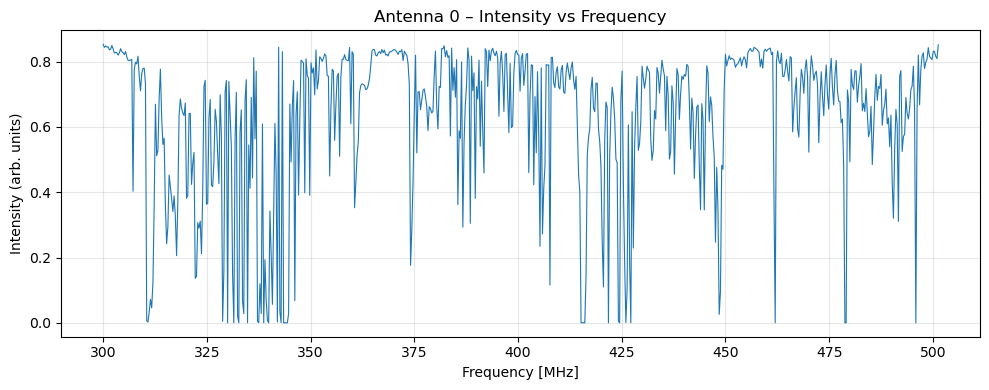

Frame shape (ant 1): (672, 150000)


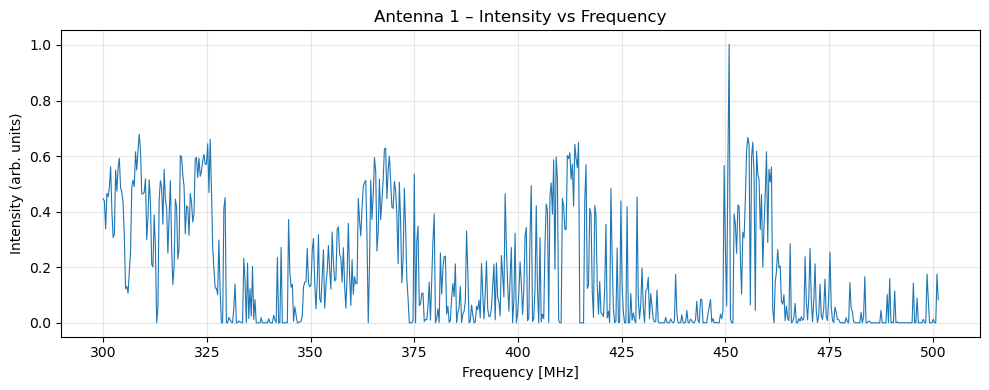

Frame shape (ant 2): (672, 150000)


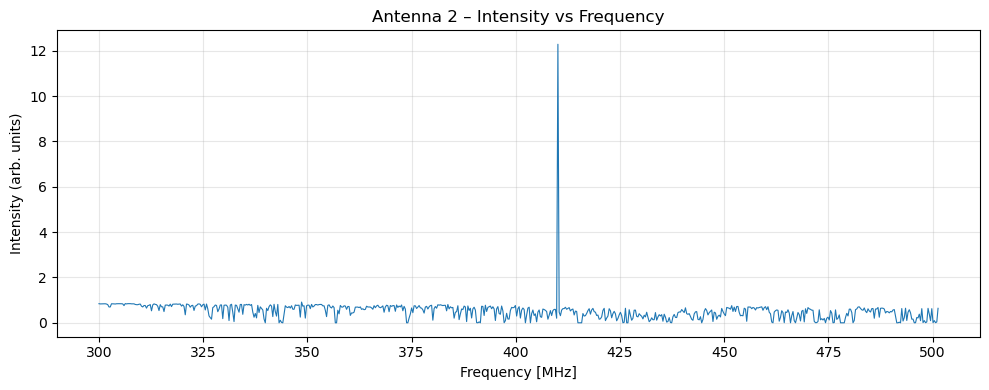

Frame shape (ant 3): (672, 150000)


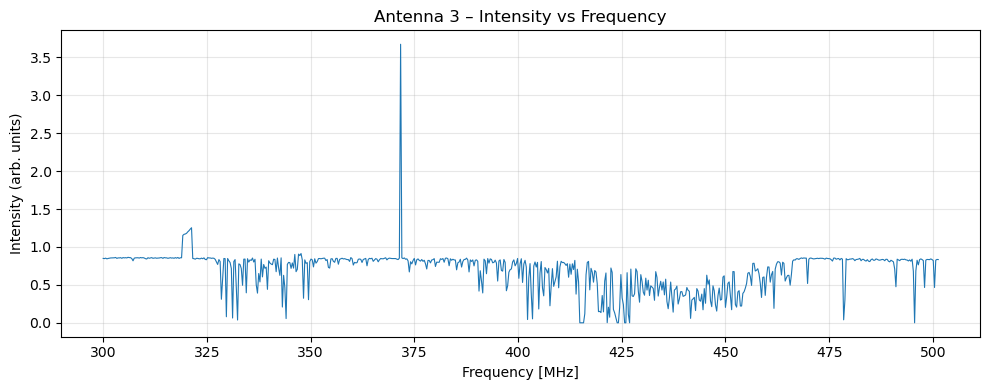

Frame shape (ant 4): (672, 150000)


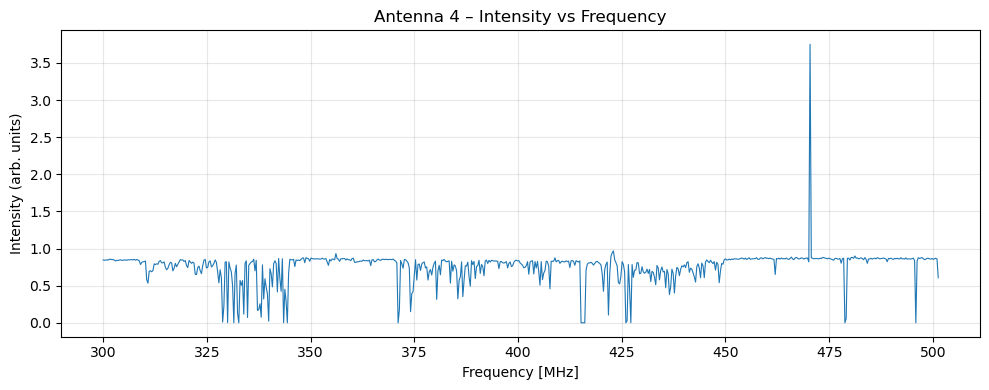

Frame shape (ant 5): (672, 150000)


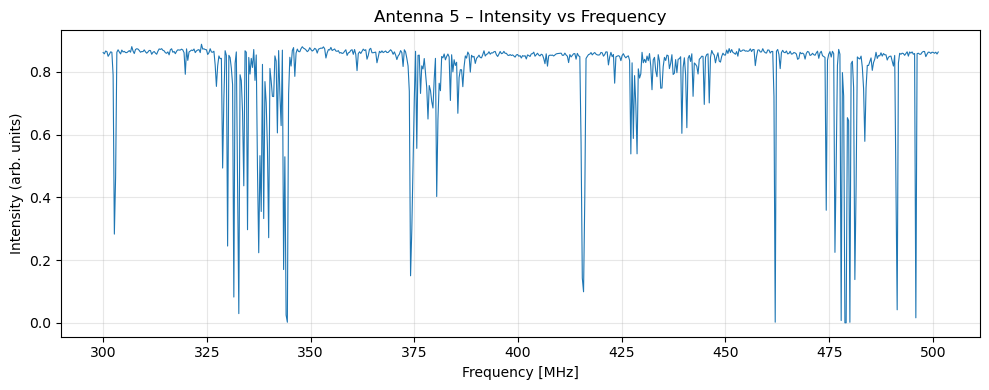

Frame shape (ant 6): (672, 150000)


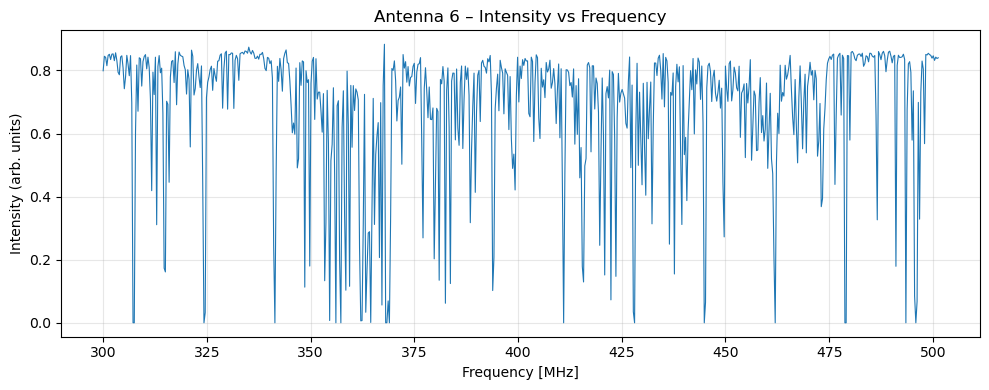

Frame shape (ant 7): (672, 150000)


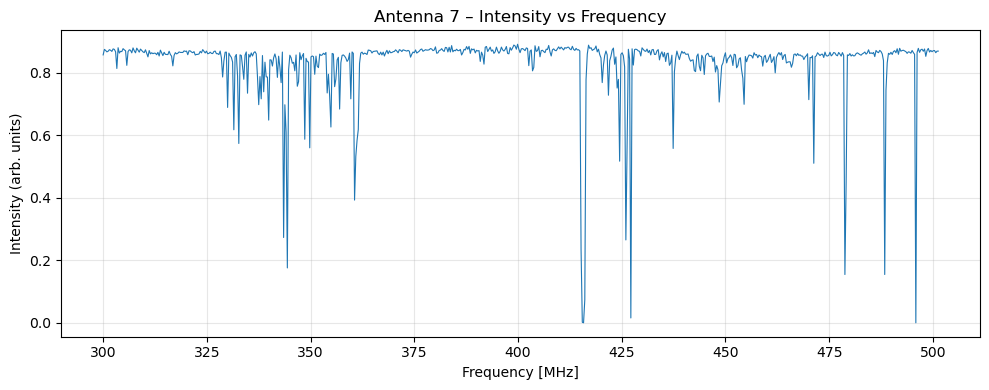

Frame shape (ant 8): (672, 150000)


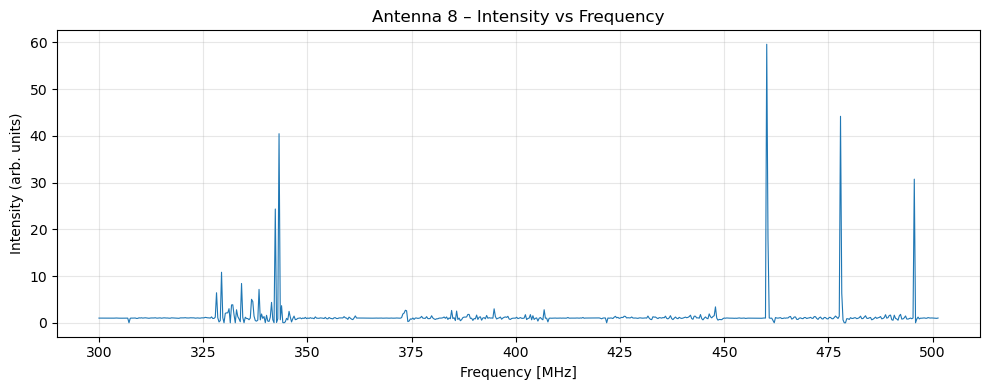

Frame shape (ant 9): (672, 150000)


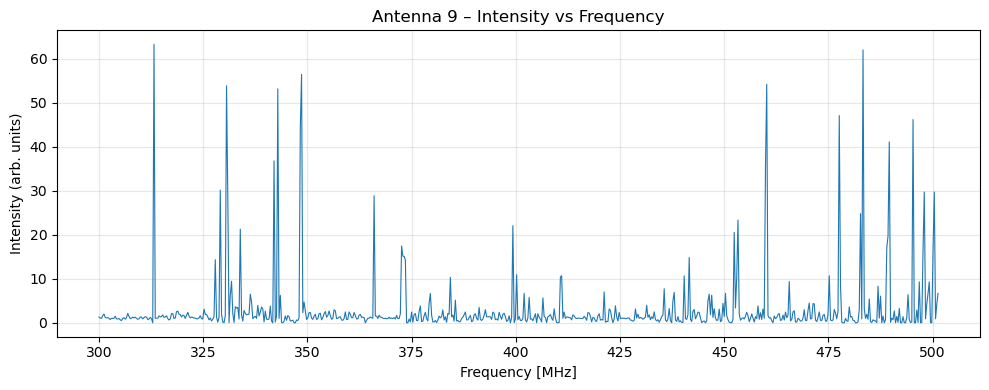

Frame shape (ant 10): (672, 150000)


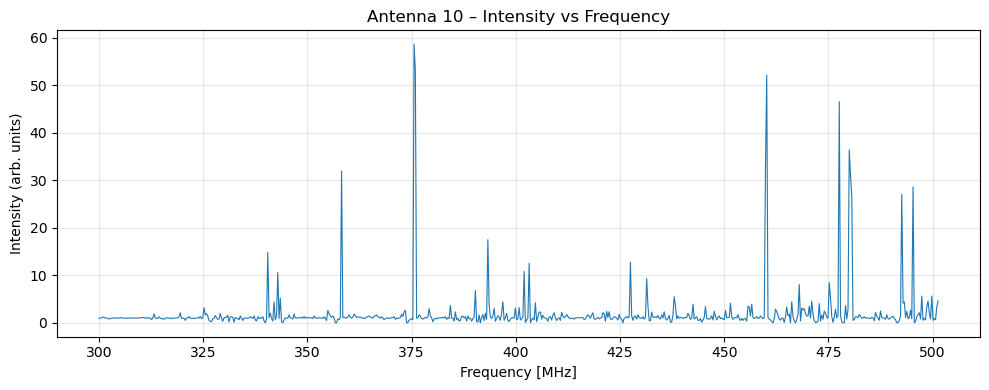

Frame shape (ant 11): (672, 150000)


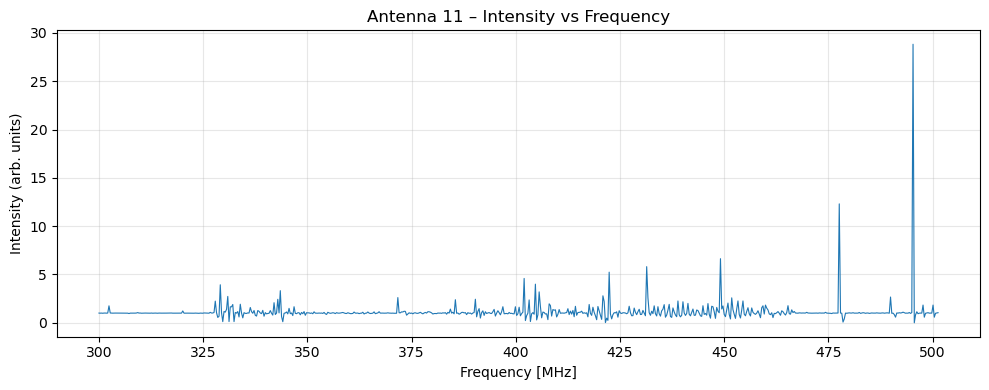

Frame shape (ant 12): (672, 150000)


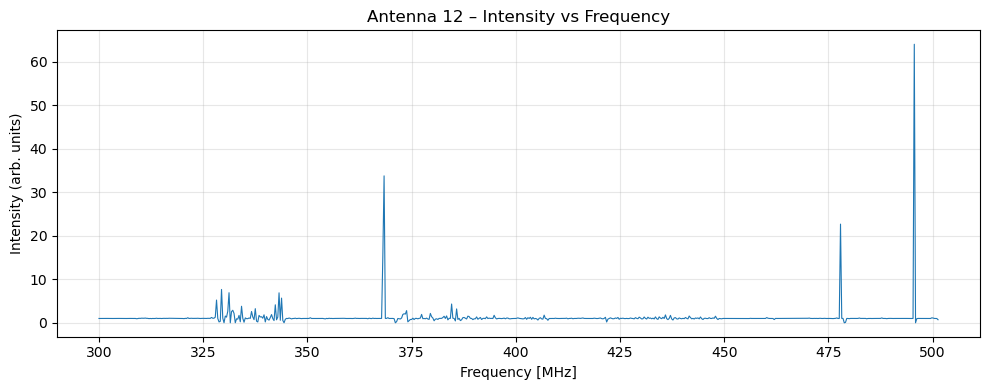

Frame shape (ant 13): (672, 150000)


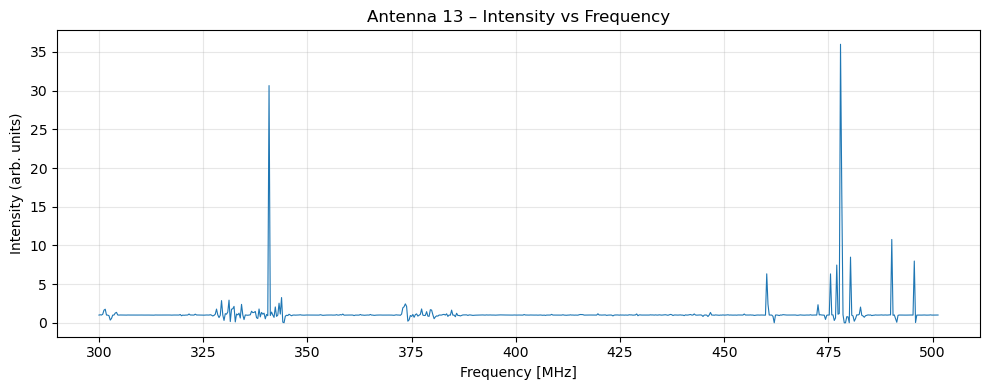

Frame shape (ant 14): (672, 150000)


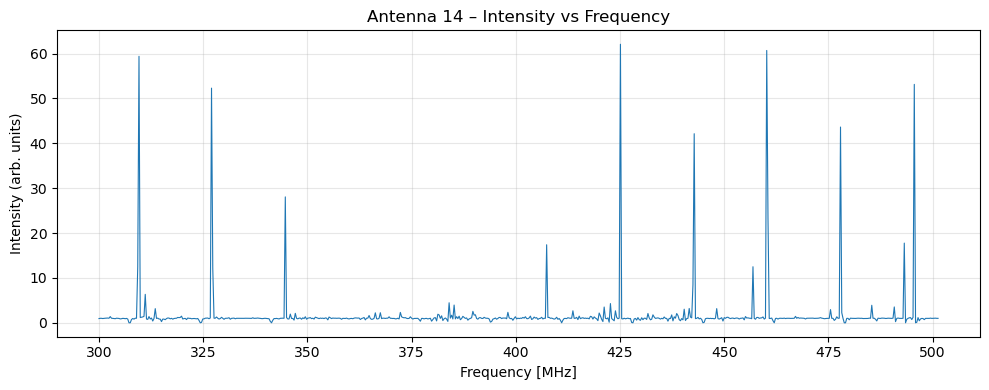

Frame shape (ant 15): (672, 150000)


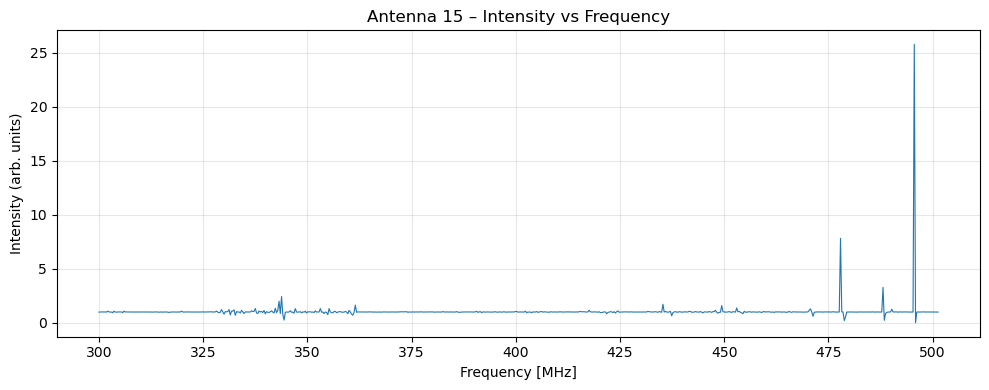

Frame shape (ant 16): (672, 150000)


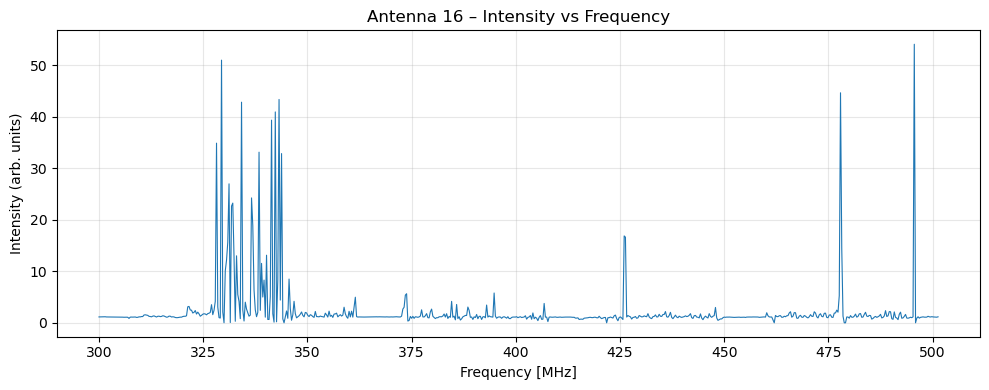

Frame shape (ant 17): (672, 150000)


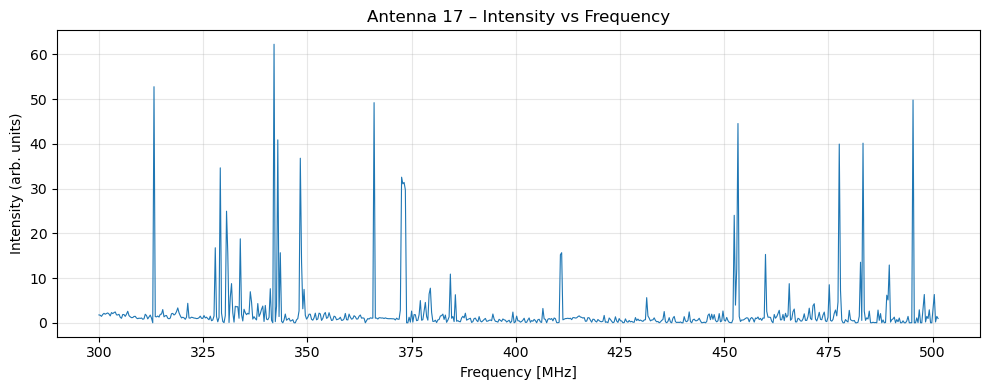

Frame shape (ant 18): (672, 150000)


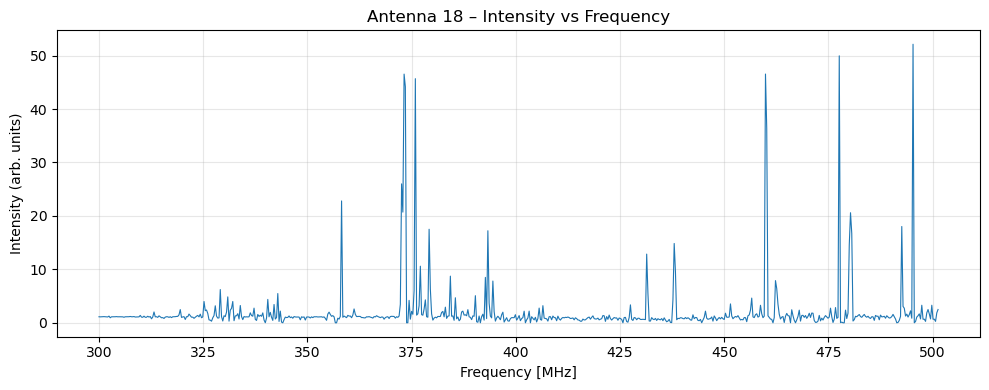

Frame shape (ant 19): (672, 150000)


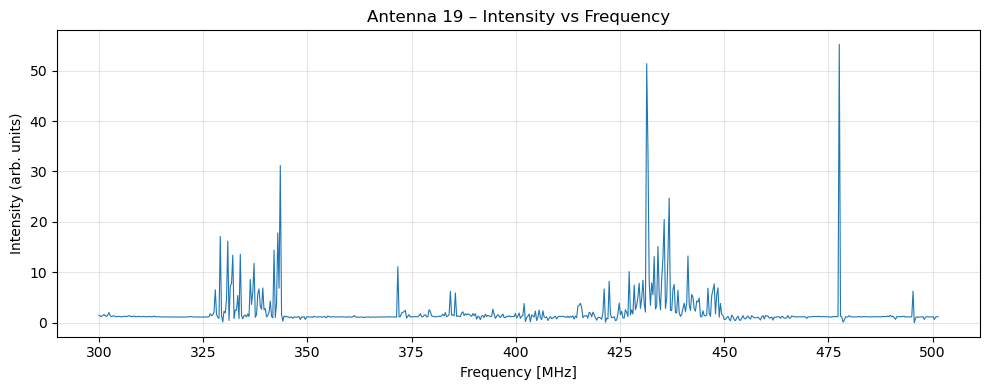

Frame shape (ant 20): (672, 150000)


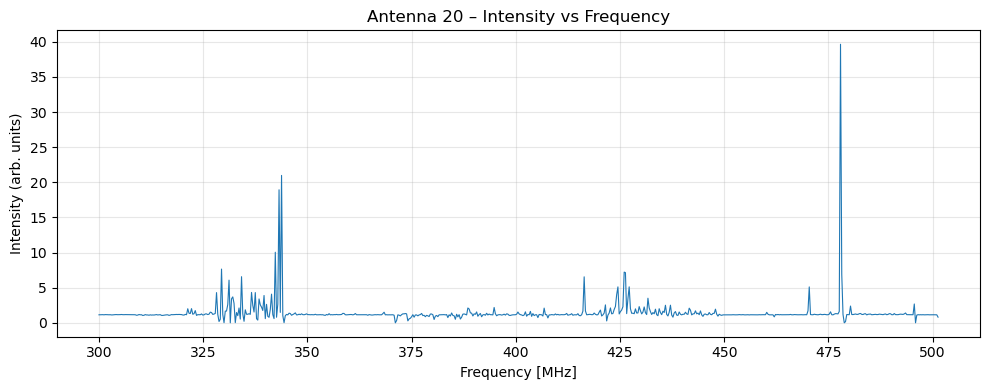

Frame shape (ant 21): (672, 150000)


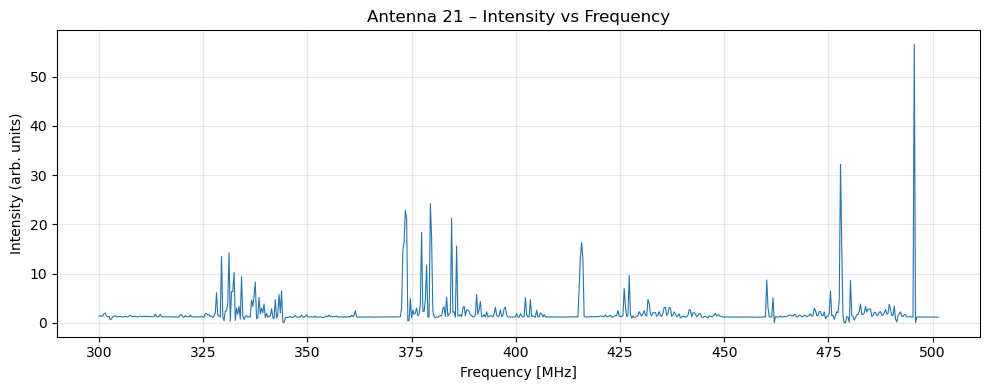

Frame shape (ant 22): (672, 150000)


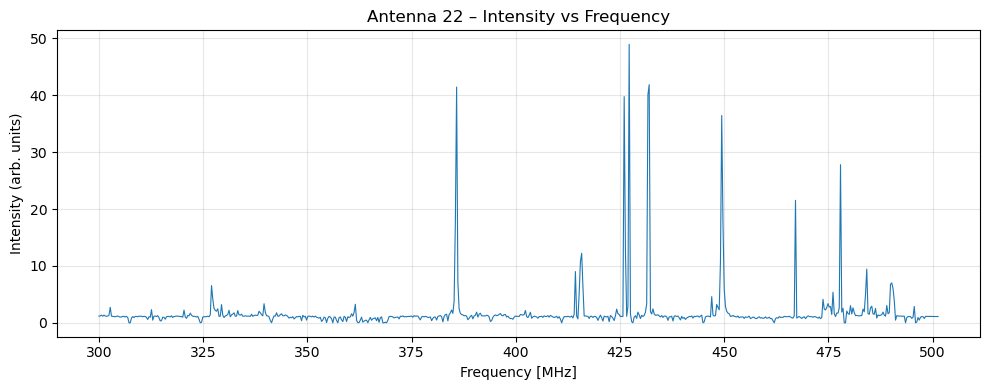

Frame shape (ant 23): (672, 150000)


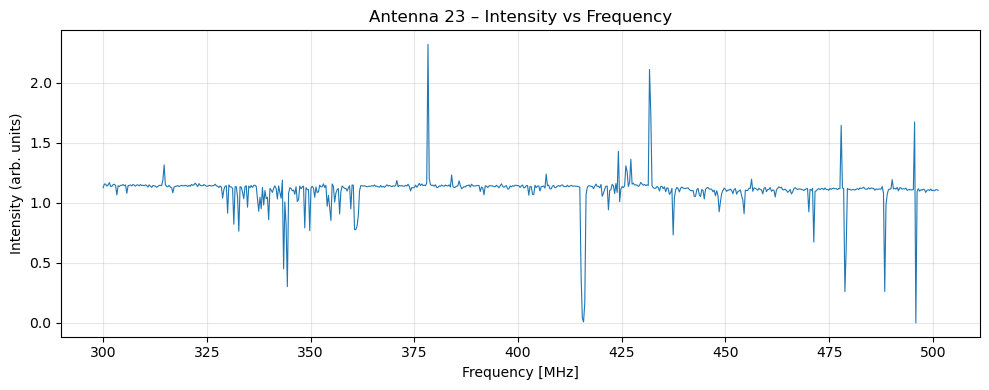

Frame shape (ant 24): (672, 150000)


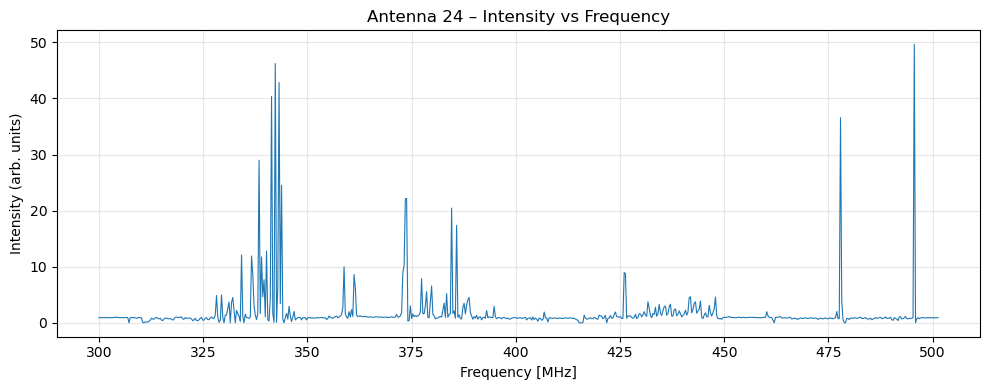

Frame shape (ant 25): (672, 150000)


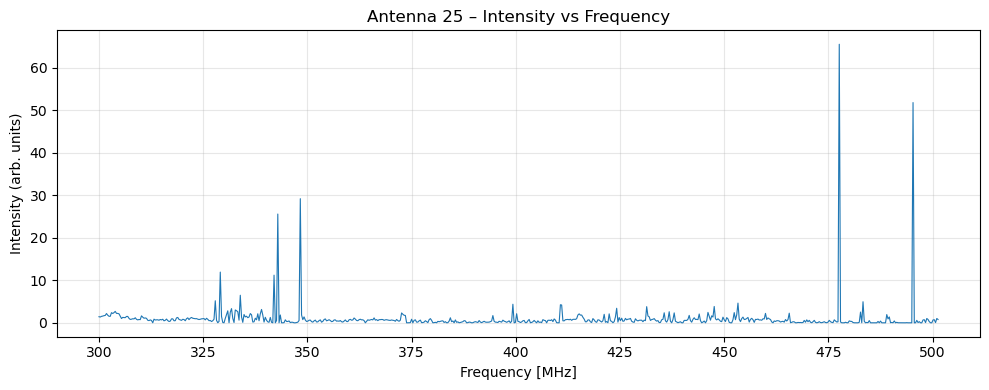

Frame shape (ant 26): (672, 150000)


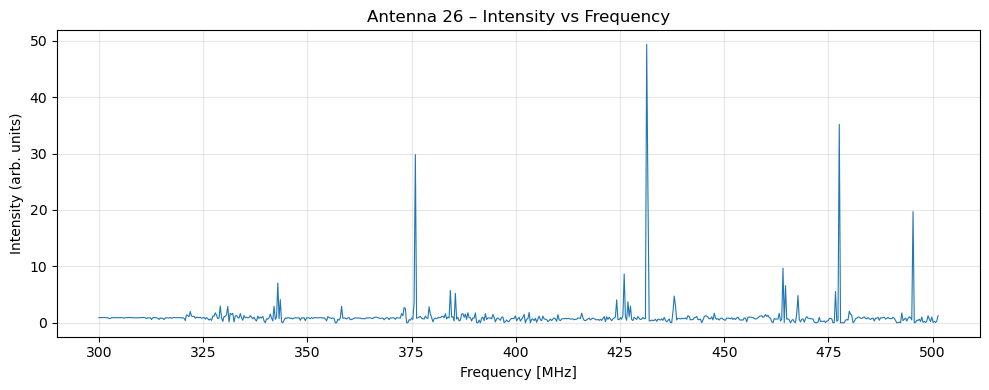

Frame shape (ant 27): (672, 150000)


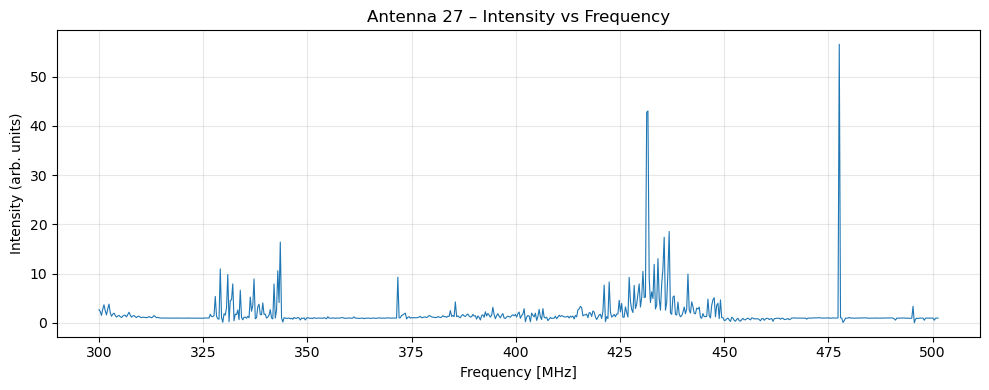

Frame shape (ant 28): (672, 150000)


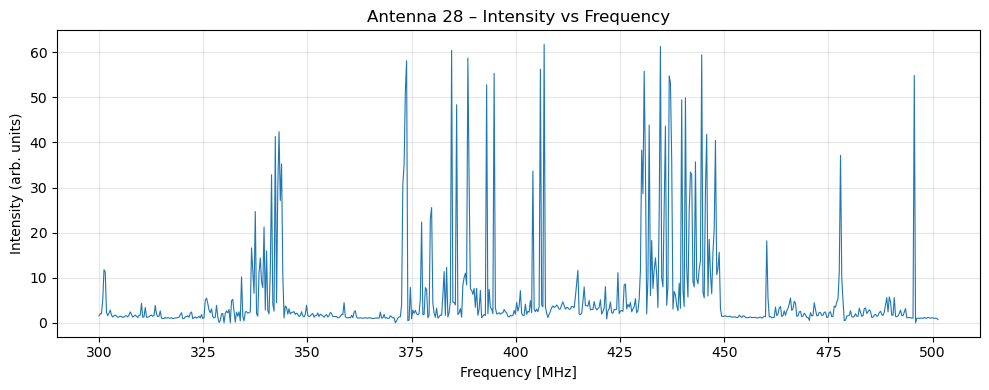

Frame shape (ant 29): (672, 150000)


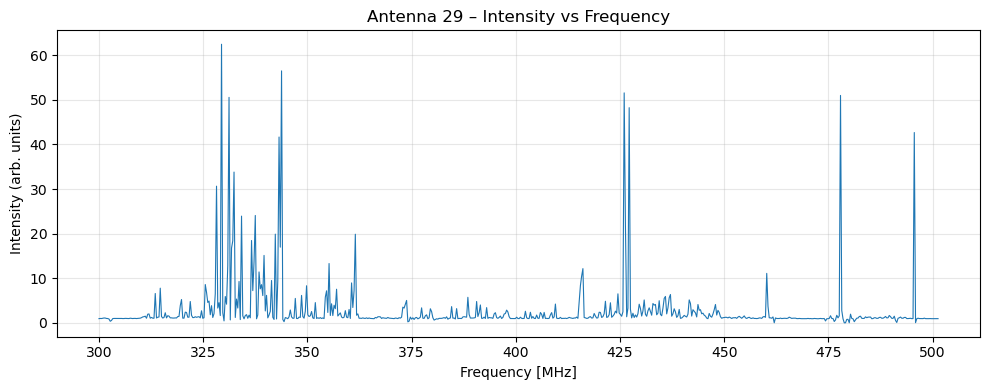

Frame shape (ant 30): (672, 150000)


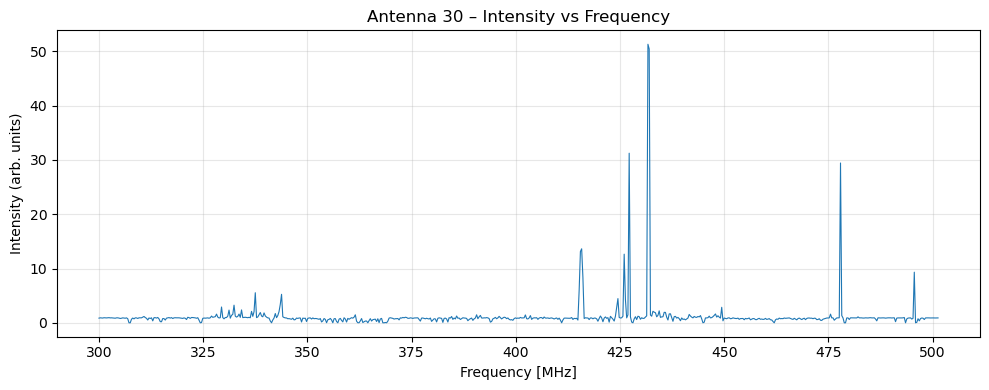

Frame shape (ant 31): (672, 150000)


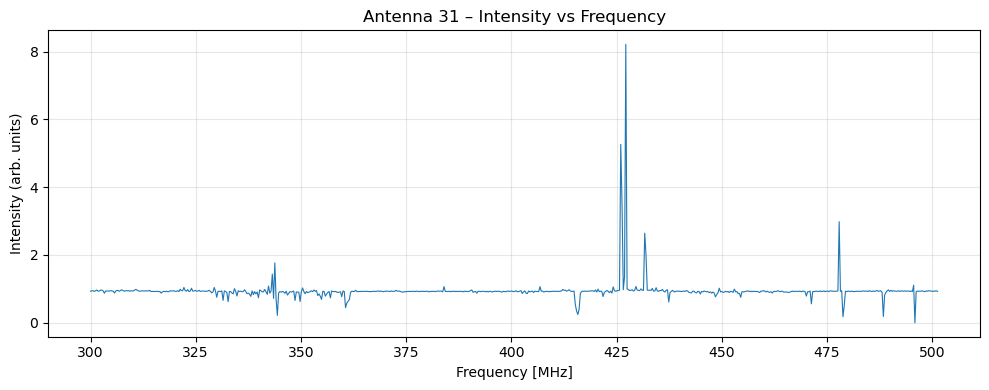

In [13]:
# Spectrum
frequencies = np.linspace(300, 501.6, n_freq, endpoint=False)  # Frequency axis

anntenas = np.linspace(0, 31, n_ant, dtype=int)

for antenna in anntenas:
    
    frame = chains[antenna, :, :]
    print(f"Frame shape (ant {antenna}):", frame.shape)

    I_mean = np.mean(np.abs(frame) ** 2, axis=1)
    
    #I_mean = 10 * np.log10(I_mean + 1e-12)  # Convert to dB, add small value to avoid log(0)

    plt.figure(figsize=(10, 4))
    plt.plot(frequencies, I_mean, lw=0.8)
    plt.xlabel("Frequency [MHz]")
    plt.ylabel("Intensity (arb. units)")
    plt.title(f"Antenna {antenna} – Intensity vs Frequency")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

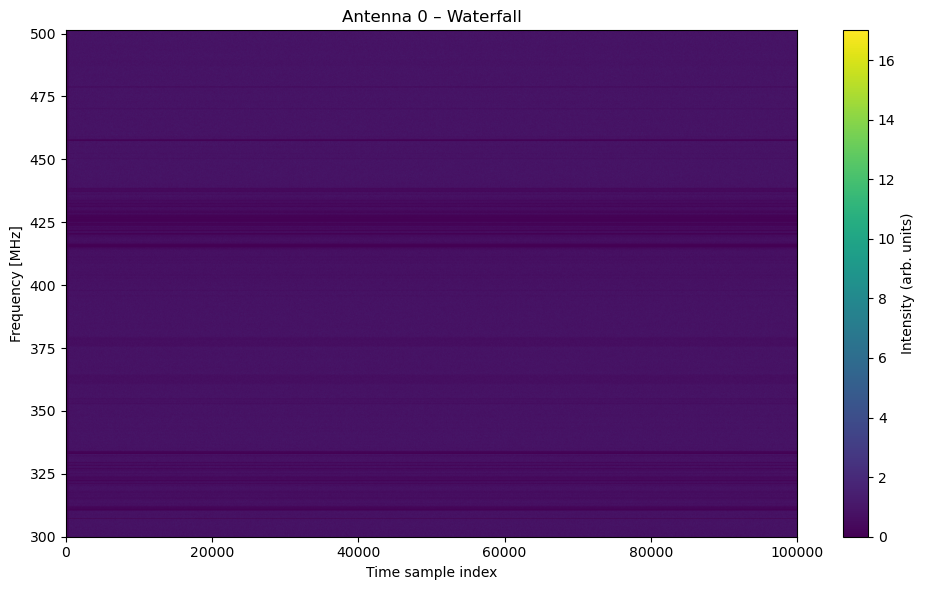

In [ ]:
I = np.abs(frame) ** 2

plt.figure(figsize=(10, 6))
plt.imshow(
    I,
    aspect="auto",
    origin="lower",
    extent=[0, frame.shape[1], frequencies[0], frequencies[-1] ],
    cmap="viridis"
)
plt.colorbar(label="Intensity (arb. units)")
plt.xlabel("Time sample index")
plt.ylabel("Frequency [MHz]")
plt.title(f"Antenna {antenna} – Waterfall")
plt.tight_layout()
plt.show()


Calculating specific correlations...


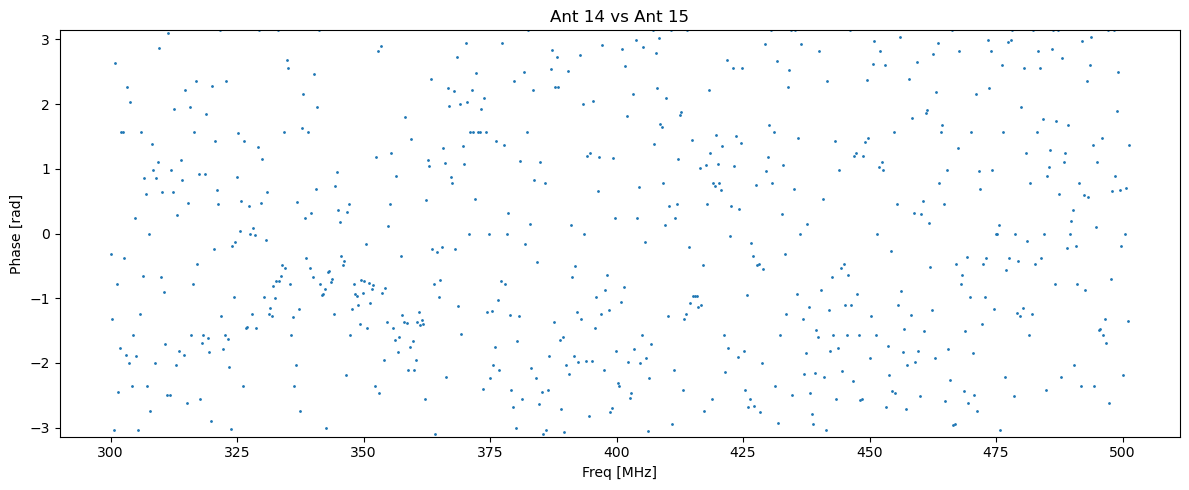

In [7]:
# Correlation of Antenna 7 with specific antennas (15, 23)
target_pairs = [(14, 15)]
n_plots = len(target_pairs)

fig, axes = plt.subplots(1, n_plots, figsize=(12, 5))
if n_plots == 1:
    axes = [axes] # Ensure iterable if only one plot

frequencies = np.linspace(300, 501.6, n_freq, endpoint=False)

print("Calculating specific correlations...")

for idx, (ant_i, ant_j) in enumerate(target_pairs):
    # Calculate correlation
    corr_spectrum = np.mean(chains[ant_i] * np.conj(chains[ant_j]), axis=1)
    phase = np.angle(corr_spectrum)
    
    ax = axes[idx]
    ax.scatter(frequencies, phase, s=1)
    ax.set_ylim(-np.pi, np.pi)
    ax.set_title(f"Ant {ant_i} vs Ant {ant_j}")
    ax.set_xlabel("Freq [MHz]")
    if idx == 0:
        ax.set_ylabel("Phase [rad]")

plt.tight_layout()
plt.show()

Calculating correlations and plotting...


/tmp/ipykernel_170500/1629844995.py:19: RuntimeWarning: invalid value encountered in divide
  corr_spectrum = corr_spectrum / np.mean(chains[30] * np.conj(chains[21]), axis=1)


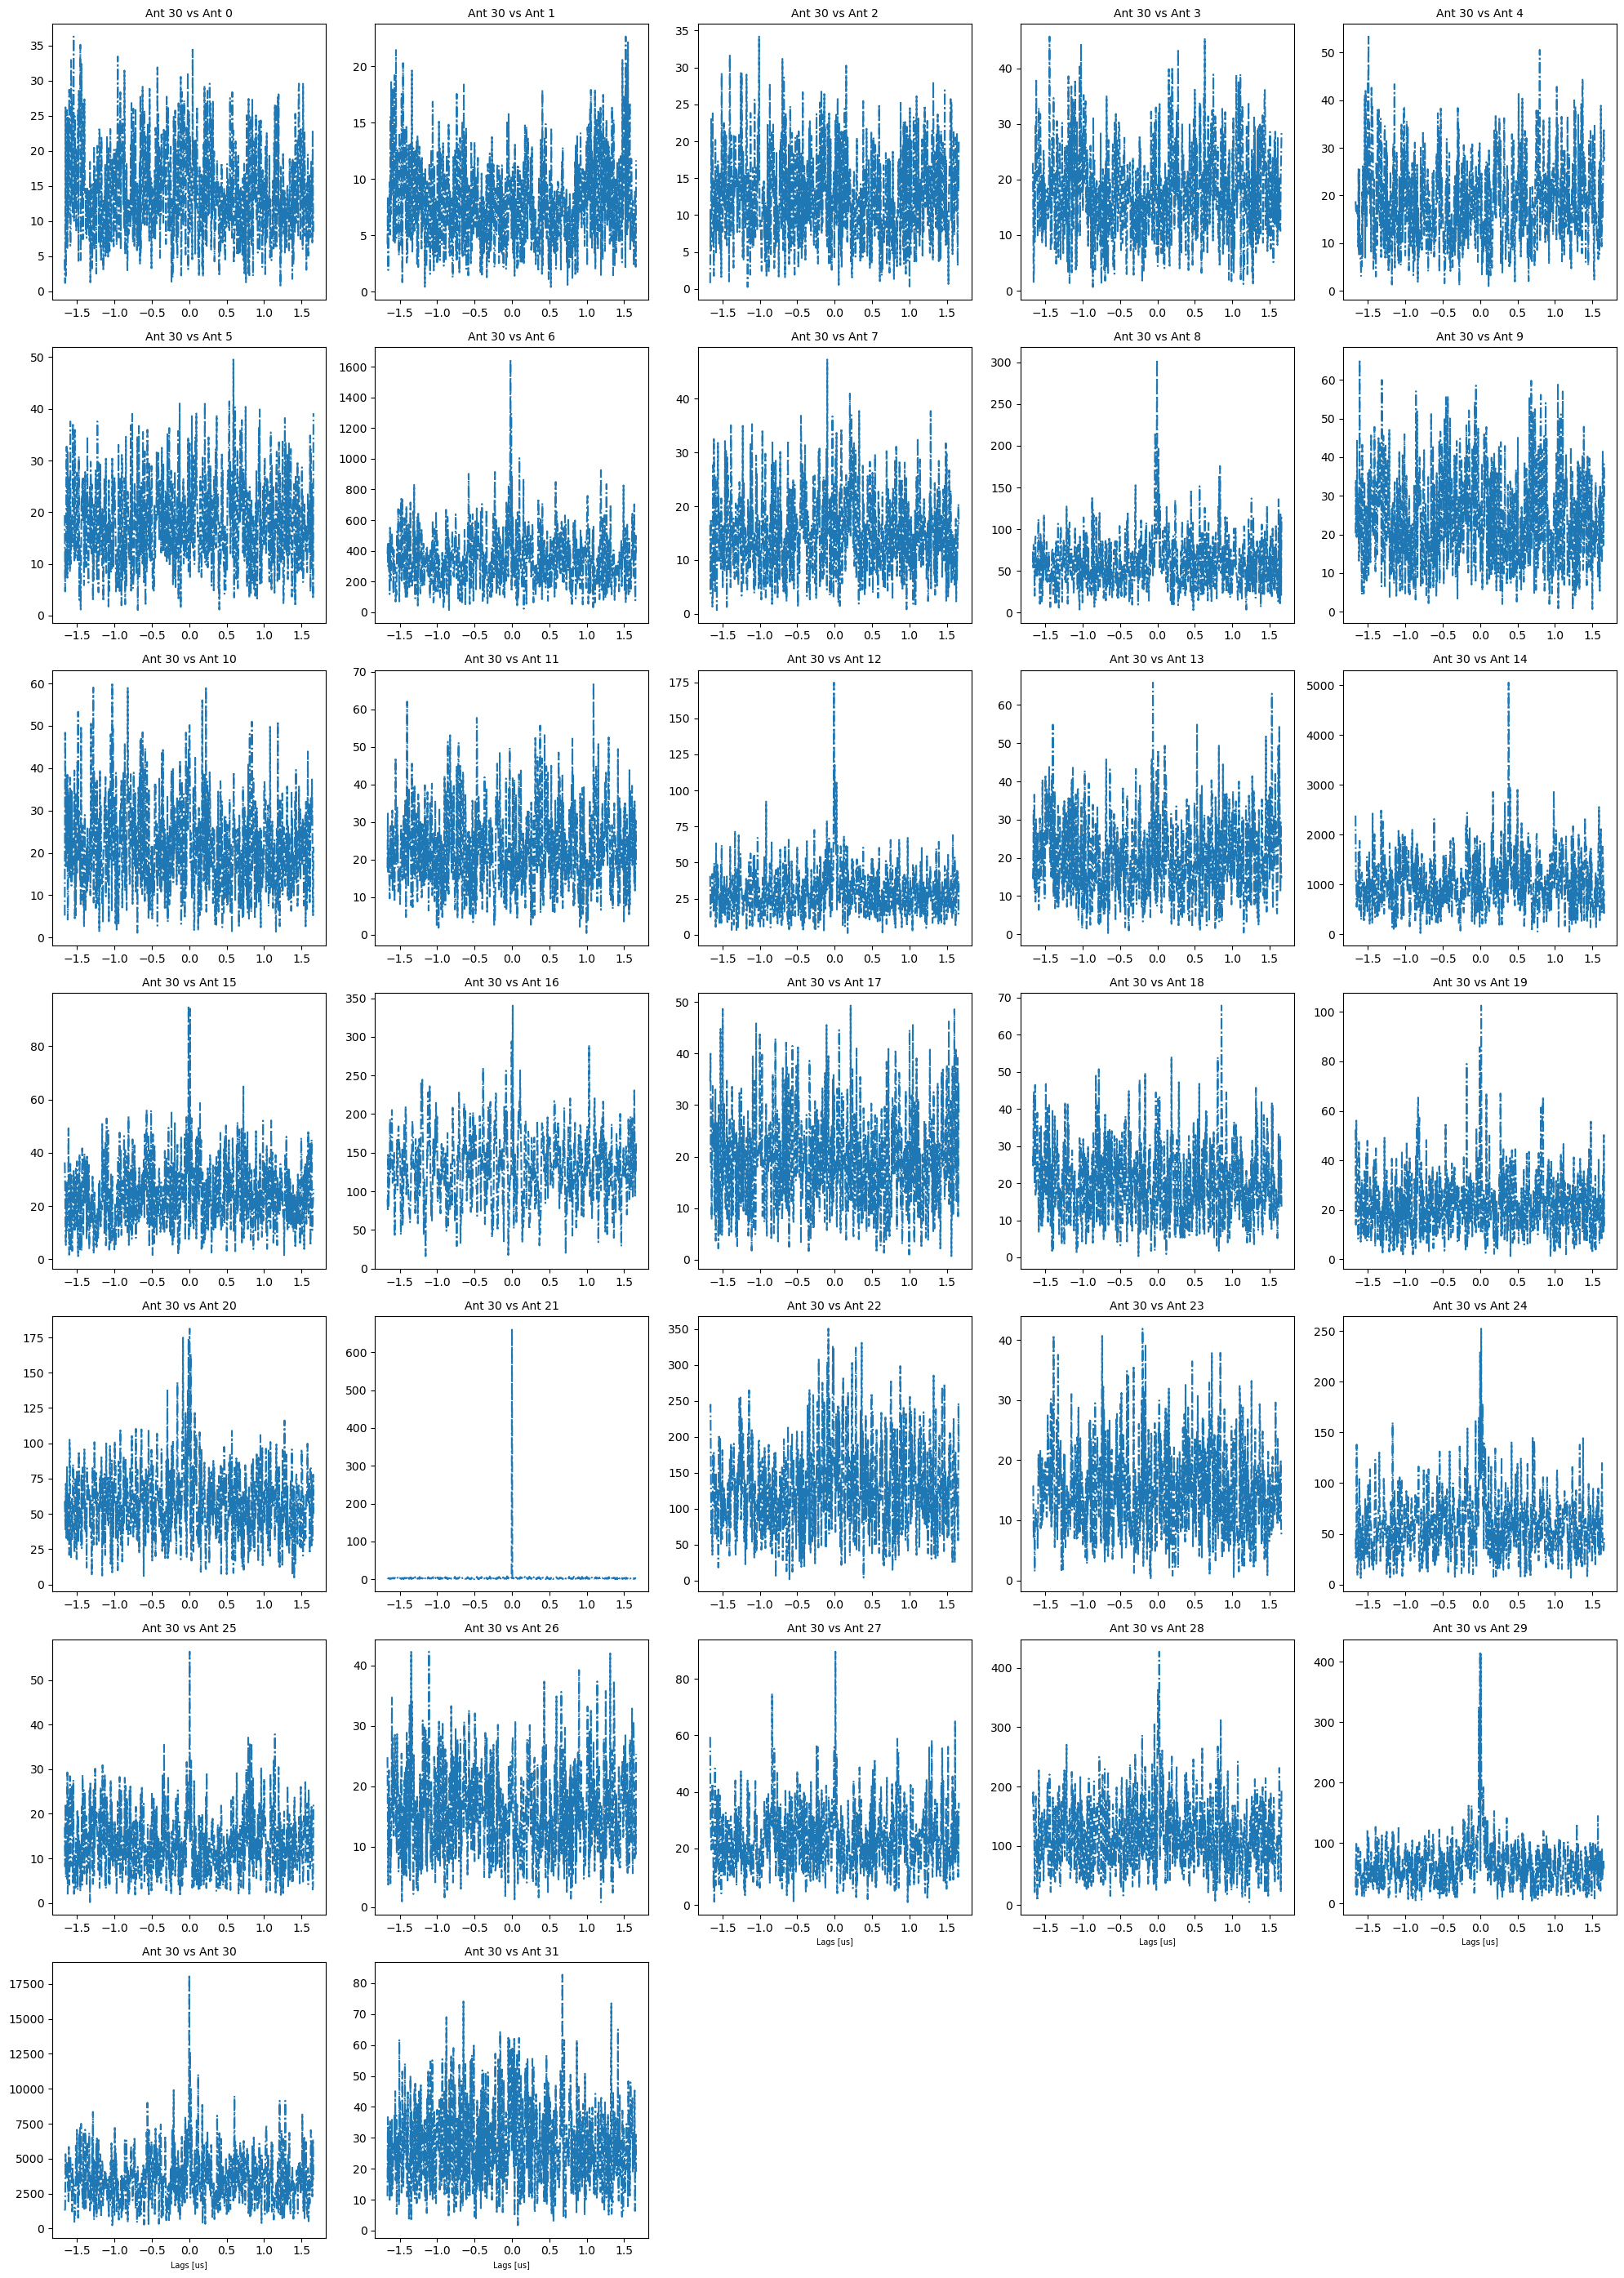

In [ ]:
# Determinar el tamaño de la grilla (ej. 4 columnas)
n_cols = 5
n_rows = int(np.ceil(n_ant / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes_flat = axes.flatten()  # Aplanar para iterar fácilmente

frequencies = np.linspace(300, 501.6, n_freq, endpoint=False)  # Frequency axis

print("Calculating correlations and plotting...")

i = 12  # Antena fija 

for j in range(n_ant):
    # Calculate correlation: Average( Antenna_0 * conj(Antenna_j) ) over time axis
    # chains[i] shape is (freq, time)
    # Result shape is (freq,)
    corr_spectrum = np.mean((chains[i] * np.conj(chains[j])), axis=1)
    corr_spectrum = corr_spectrum / np.mean(chains[12] * np.conj(chains[13]), axis=1)
    phase = np.angle(corr_spectrum)
    corr_lag = np.abs(np.fft.fftshift(np.fft.fft(np.nan_to_num(corr_spectrum))))

    lags = np.fft.fftshift(np.fft.fftfreq(len(corr_spectrum), d=1/3.33))
    
    ax = axes_flat[j]
    ax.plot(lags, corr_lag, "-.")
    #ax.set_ylim(-2*np.pi, 2*np.pi)  
    ax.set_title(f"Ant {i} vs Ant {j}", fontsize=10)

    # Etiquetado básico
    if j >= n_ant - n_cols:
        ax.set_xlabel("Lags [us]", fontsize=7)

# Ocultar subplots vacíos
for k in range(n_ant, len(axes_flat)):
    axes_flat[k].axis('off')

plt.tight_layout()
plt.show()

In [21]:
corr_spectrum

array([ 2.26169094e-01+3.63630414e-01j,  1.46487534e-01+2.17010602e-01j,
        3.25547367e-01+9.80763212e-02j,  1.13764715e+00-2.22209632e-01j,
        5.95169306e-01+1.68687612e-01j,  4.50048208e-01+2.23758876e-01j,
        2.78990656e-01+9.96113941e-02j,  8.43141973e-02-8.45679194e-02j,
        3.96875173e-01+1.63509443e-01j,  4.09063727e-01+2.58412838e-01j,
        2.43864864e-01+2.94008136e-01j,  1.95341170e-01+2.78965056e-01j,
        3.60777318e-01+1.76678017e-01j,  3.14885318e-01+1.93017334e-01j,
        6.77111447e-01-5.97545691e-02j,  1.39309204e+00+6.90493226e-01j,
        3.94290656e-01+5.67627966e-01j,  6.53436422e-01+1.22709490e-01j,
        8.74240696e-01+3.29558849e-01j, -3.30281444e-02+4.40910071e-01j,
        4.24503624e-01-6.67118579e-02j,  4.05838042e-01-1.42604202e-01j,
        3.78536850e-01+2.38359541e-01j,  2.17072621e-01+2.34566350e-02j,
        3.79182130e-01-9.29367915e-02j,             nan           +nanj,
        2.06779540e-01+3.10321242e-01j,  7.51589656